In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
from pprint import pprint
import gc
from sklearn.model_selection import train_test_split
from datetime import datetime

In [2]:
!pip install catboost
import catboost as cb

In [3]:
!pip install xgboost
import xgboost as xgb

In [87]:
ml_path = Path.cwd()
base_path = ml_path.parent
data_path = base_path / 'data_preparation' / 'data'
clean_data_path = data_path / 'clean'
clean_data_file = clean_data_path / 'clean_data_with_regions.xlsx'

In [107]:
CLEAN_DATA = pd.read_excel(clean_data_file)

In [167]:
TRIMMED_DATA = CLEAN_DATA.drop(['lead_tags', 'contact_Город', 'contact_id', 'lead_id', 'lead_Состав заказа', 'lead_yclid'], axis = 1)
del CLEAN_DATA
gc.collect()

16600

In [168]:
TRIMMED_DATA = TRIMMED_DATA.drop(['sale_date', 'closed_ts', 'received_ts', 'rejected_ts', 'returned_ts', 'days_to_outcome', 'lead_Условный отказ', 
                                 'lead_Оплата МОП', 'is_paid_mop', 'lead_Дата получения денег на Р/С', 'lead_Источник', 'lead_Дата создания сделки', 'price_group'], axis = 1)

In [175]:
(~TRIMMED_DATA[~TRIMMED_DATA['has_promo']]['lead_Скидка'].isna()).sum()

np.int64(2202)

In [106]:
TRIMMED_DATA.info()

NameError: name 'TRIMMED_DATA' is not defined

In [166]:
def sig3OutlDetector(DATA, columns):
    Stds = DATA[columns].std()
    Means = DATA[columns].mean()
    CrvdDATA = DATA[columns]
    CrvdDATA = CrvdDATA[((-3*Stds+Means<=CrvdDATA)&(3*Stds+Means>=CrvdDATA))[columns[0]]]
    return DATA.iloc[CrvdDATA.index.tolist()].reset_index(drop = True)
def bool2flag(DATA):
    DAT = DATA.copy()
    cols = DAT.select_dtypes(['bool']).columns.tolist()
    DAT[cols] = DAT[cols]*1
    return DAT
def Nan2Missing(DATA):
    DAT = DATA.copy()
    cols = DAT.select_dtypes(['object']).columns.tolist()
    DAT[cols] = DAT[cols].fillna('ПРОПУСК')
    return DAT
def ReplacingTS(DATA, stages):
    st = stages[::-1]
    DAT = DATA.copy()
    for idx, ts_col_1 in enumerate(st[:-1]):
        for ts_col_2 in st[idx+1:]:
            DAT[ts_col_1].fillna(DAT[ts_col_2][DAT[ts_col_1].isna()], inplace = True)
            if DAT[ts_col_1].isna().sum()==0:
                break
    return DAT
def Nan2Adequate(DATA, last_stage = None):
    DAT = DATA.copy()
    DAT[['lead_Скидка']] = DAT[['lead_Скидка']].fillna(0)
    DAT[['lead_Квалификация лида']].fillna('Неквал лид', inplace = True)
    DAT[['lead_source_category']].fillna('organic', inplace = True)
    DAT[['contact_LTV', 'contact_Число сделок']] = DAT[['contact_LTV', 'contact_Число сделок']].fillna(0)
    DAT.dropna(subset= ['delivery_group', 'delivery_days', 'lead_Тариф Доставки'], inplace = True, ignore_index = True)
    DAT = Nan2Missing(DAT)
    stages = ['sale_ts', 'lead_Дата перехода в Сборку', 'handed_to_delivery_ts', 'issued_or_pvz_ts']
    if not (last_stage is None):
        drop = stages[stages.index(last_stage):]
        DAT.drop(drop, axis = 1, inplace = True)
        stages = stages[:stages.index(last_stage)]
    DAT = ReplacingTS(DAT, stages)
    return DAT

In [112]:
EMBEDDED_DATA = bool2flag(TRIMMED_DATA)
del TRIMMED_DATA
gc.collect()

96

In [113]:
EMBEDDED_DATA = sig3OutlDetector(EMBEDDED_DATA, ['lead_price'])

In [114]:
EMBEDDED_DATA = Nan2Adequate(EMBEDDED_DATA)

C:\Users\andra\AppData\Local\Temp\ipykernel_21624\3479063195.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAT[['lead_Квалификация лида']].fillna('Неквал лид', inplace = True)
C:\Users\andra\AppData\Local\Temp\ipykernel_21624\3479063195.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAT[['lead_source_category']].fillna('organic', inplace = True)
C:\Users\andra\AppData\Local\Temp\ipykernel_21624\3479063195.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will ne

In [115]:
Y = EMBEDDED_DATA[['buyout_flag']]
X = EMBEDDED_DATA.drop('buyout_flag', axis = 1)
Features_titles = X.columns.tolist()
del EMBEDDED_DATA
gc.collect()

0

In [118]:
X.isna().sum()

sale_ts                        0
handed_to_delivery_ts          0
issued_or_pvz_ts               0
lead_price                     0
lead_responsible_user_id       0
lead_Служба доставки           0
lead_Вид оплаты                0
lead_Проблема                  0
contact_LTV                    0
contact_Число сделок           0
lead_Тариф Доставки            0
lead_Скидка                    0
lead_Квалификация лида         0
lead_Дата перехода в Сборку    0
has_yclid                      0
is_repeat_client               0
has_promo                      0
lead_source_category           0
is_yur                         0
has_маска                      0
has_наколенник                 0
has_бандаж_шейный              0
has_повязка                    0
has_напульсник                 0
has_обувь                      0
has_подушка                    0
has_матрас                     0
has_пояс                       0
has_аксессуары                 0
has_крем                       0
n_product_

<h1>Эмбеддинги для категориальных признаков</h1>
Категориальные признаки можно эмбеддить по-разному.
На базовом уровне можно использовать one-hot кодирование.
Более сложная альтернатива - предобученные эмбеддеры, которые представлены ниже.

~~В сущности идея плохая из-за чересчур большой размерности любой предобученной модели-эмбеддера (128 - минимум), что слишком раздувает датасет. Проблема кроется в том, что раздутый датасет раздувает ещё и количество весов у моделей. Например, для стандартных линейных нейросетей датасеты с 1000 столбцов дают миллионы весов, в то время как у нас доступно лишь около 20 тыс. задач.~~

In [5]:
'''Эмбеддинг от OpenAI стоит денег. (5$)'''
from openai import OpenAI
import os

In [2]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
texts = [['Where is Gamora?', 'Who is Gamora?', 'Why is Gamora?'], ['Где Гамора?', 'Кто такая Гамора?', 'Зачем Гамора?']]
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

In [4]:
model.encode(texts[0])

array([[ 0.05880972, -0.06816842, -0.02992232, ...,  0.0216549 ,
        -0.30306318, -0.05126128],
       [-0.3230412 ,  0.06128931, -0.15995002, ..., -0.06036611,
        -0.05101767,  0.01018321],
       [-0.21942565,  0.0009592 , -0.14654882, ...,  0.13390388,
         0.30188185, -0.02924955]], shape=(3, 384), dtype=float32)

In [3]:
TextEmbedding.list_supported_models()

[{'model': 'BAAI/bge-base-en',
  'sources': {'hf': 'Qdrant/fast-bge-base-en',
   'url': 'https://storage.googleapis.com/qdrant-fastembed/fast-bge-base-en.tar.gz',
   '_deprecated_tar_struct': True},
  'model_file': 'model_optimized.onnx',
  'description': 'Text embeddings, Unimodal (text), English, 512 input tokens truncation, Prefixes for queries/documents: necessary, 2023 year.',
  'license': 'mit',
  'size_in_GB': 0.42,
  'additional_files': [],
  'dim': 768,
  'tasks': {}},
 {'model': 'BAAI/bge-base-en-v1.5',
  'sources': {'hf': 'qdrant/bge-base-en-v1.5-onnx-q',
   'url': 'https://storage.googleapis.com/qdrant-fastembed/fast-bge-base-en-v1.5.tar.gz',
   '_deprecated_tar_struct': True},
  'model_file': 'model_optimized.onnx',
  'description': 'Text embeddings, Unimodal (text), English, 512 input tokens truncation, Prefixes for queries/documents: not so necessary, 2023 year.',
  'license': 'mit',
  'size_in_GB': 0.21,
  'additional_files': [],
  'dim': 768,
  'tasks': {}},
 {'model':

In [2]:
from fastembed import TextEmbedding
texts = [['Where is Gamora?', 'Who is Gamora?', 'Why is Gamora?'], ['Где Гамора?', 'Кто такая Гамора?', 'Зачем Гамора?']]
model = TextEmbedding(model_name="intfloat/multilingual-e5-small")

ValueError: Model intfloat/multilingual-e5-small is not supported in TextEmbedding. Please check the supported models using `TextEmbedding.list_supported_models()`

In [8]:
from sentence_transformers import SentenceTransformer
ST = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

In [14]:
def epSec2Datetime(df):
    for col in df.columns.tolist():
        df[col] = pd.to_datetime(df[col], unit = 's')
    return df
def datetime2EpSec(df):
    columns = df.select_dtypes(['datetime64[ns]']).columns.tolist()
    for col in columns:
        df[col] = (df[col] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
    return df
def Transpose(x):
    X = [[i] for i in x[0]]
    for i in x[1:]:
        for idx, j in enumerate(i):
            X[idx].append(j)
    return X
def CategoricalUniform(DATA):
    CUdData = {}
    for label in DATA.columns.tolist():
        column = DATA[label]
        unique = pd.unique(column).tolist()
        transformDict = {i: j for i, j in zip(unique, range(len(unique)))}
        CUdData[label] = column.apply(lambda x: transformDict[x])
    return pd.DataFrame(CUdData)
def DataPrep(df, st_embed_categories = False, fe_embed_categories = False, oh_embed_categories = False):
    temp = df.copy()
    if st_embed_categories:
        global ST
        str_columns = df.select_dtypes(['object']).columns.tolist()
        for col in tqdm(str_columns):
            T = ST.encode([i for i in temp[col].to_dict().values()])
            Tcols = [col+f'_{i+1}' for i in range(T.shape[1])]
            t = pd.DataFrame(data = T, columns = Tcols)
            temp = temp.drop(col, axis = 1)
            temp = pd.concat([temp, t], axis = 1)
    elif fe_embed_categories:
        pass
    elif oh_embed_categories:
        str_columns = df.select_dtypes(['object']).columns.tolist()
        temp[str_columns] = CategoricalUniform(temp[str_columns])
    return Transpose([[j for j in i.values()] for i in datetime2EpSec(temp).to_dict().values()])

In [28]:
len(x[0])

3100

In [119]:
X = DataPrep(X, oh_embed_categories=True)
Y = DataPrep(Y, oh_embed_categories=True)

In [16]:
test_size = 0.2

In [120]:
TrainDataset, TestDataset, TrainLabels, TestLabels = train_test_split(X, Y, test_size=test_size)
del X, Y
gc.collect()

0

In [18]:
import torch as th

In [19]:
depth = 10
trees = 5000
lr = 1e-2
earStop = 20
seed = 42
classes = 2

In [20]:
Version = 'MK1'

In [141]:
device = 'cuda' if th.cuda.is_available() else 'cpu'
XGB_Classifier = xgb.XGBClassifier(
    max_depth = depth,
    learning_rate = lr,
    n_estimators = trees,
    objective = 'binary:logistic',
    device = device,
    scale_pos_weight = (np.asarray(TrainLabels) == 0).sum()/(np.asarray(TrainLabels) == 1).sum(),
    #num_class = classes,
    eval_metric = ['auc'],
    early_stopping_rounds=earStop,
    seed = seed
)

In [127]:
device = 'GPU' if th.cuda.is_available() else 'CPU'
CB_Classifier = cb.CatBoostClassifier(
    num_trees = trees,
    depth = depth,
    learning_rate = lr,
    task_type = device,
    #classes_count = classes,
    loss_function = 'Logloss',
    auto_class_weights = 'Balanced',
    eval_metric='AUC',
    early_stopping_rounds=earStop
)

In [23]:
xgbStart = 0
xgbEnd = 0
cbStart = 0
cbEnd = 0

In [142]:
xgbStart = datetime.now()
XGB_Classifier.fit(
    TrainDataset, TrainLabels,
    eval_set = [(TrainDataset, TrainLabels), (TestDataset, TestLabels)],
    verbose = True
)
xgbEnd = datetime.now()
xgbBestTime = str(xgbEnd-xgbStart).split(':')[-1]
xgbTotalTime = xgbBestTime

[0]	validation_0-auc:0.94989	validation_1-auc:0.93610
[1]	validation_0-auc:0.94990	validation_1-auc:0.93613
[2]	validation_0-auc:0.95004	validation_1-auc:0.93649
[3]	validation_0-auc:0.95004	validation_1-auc:0.93652
[4]	validation_0-auc:0.95006	validation_1-auc:0.93652
[5]	validation_0-auc:0.95006	validation_1-auc:0.93651
[6]	validation_0-auc:0.95037	validation_1-auc:0.93640
[7]	validation_0-auc:0.95043	validation_1-auc:0.93641
[8]	validation_0-auc:0.95039	validation_1-auc:0.93648
[9]	validation_0-auc:0.95042	validation_1-auc:0.93648
[10]	validation_0-auc:0.95762	validation_1-auc:0.94314
[11]	validation_0-auc:0.95771	validation_1-auc:0.94305
[12]	validation_0-auc:0.95876	validation_1-auc:0.94326
[13]	validation_0-auc:0.95876	validation_1-auc:0.94327
[14]	validation_0-auc:0.95876	validation_1-auc:0.94304
[15]	validation_0-auc:0.95901	validation_1-auc:0.94322
[16]	validation_0-auc:0.95912	validation_1-auc:0.94322
[17]	validation_0-auc:0.95916	validation_1-auc:0.94324
[18]	validation_0-au

In [128]:
cbStart = datetime.now()
CB_Classifier.fit(
    TrainDataset, TrainLabels,
    eval_set = (TestDataset, TestLabels),
    verbose = True
)
cbEnd = datetime.now()
cbBestTime = str(cbEnd-cbStart).split('.')[0]
cbTotalTime = cbBestTime

0:	test: 0.9365326	best: 0.9365326 (0)	total: 38ms	remaining: 3m 10s
1:	test: 0.9386756	best: 0.9386756 (1)	total: 77.7ms	remaining: 3m 14s
2:	test: 0.9404968	best: 0.9404968 (2)	total: 90.7ms	remaining: 2m 31s
3:	test: 0.9403961	best: 0.9404968 (2)	total: 130ms	remaining: 2m 42s
4:	test: 0.9397525	best: 0.9404968 (2)	total: 139ms	remaining: 2m 19s
5:	test: 0.9426459	best: 0.9426459 (5)	total: 179ms	remaining: 2m 28s
6:	test: 0.9436829	best: 0.9436829 (6)	total: 217ms	remaining: 2m 34s
7:	test: 0.9431824	best: 0.9436829 (6)	total: 261ms	remaining: 2m 43s
8:	test: 0.9429965	best: 0.9436829 (6)	total: 279ms	remaining: 2m 34s
9:	test: 0.9428079	best: 0.9436829 (6)	total: 337ms	remaining: 2m 48s
10:	test: 0.9452481	best: 0.9452481 (10)	total: 376ms	remaining: 2m 50s
11:	test: 0.9462477	best: 0.9462477 (11)	total: 415ms	remaining: 2m 52s
12:	test: 0.9468857	best: 0.9468857 (12)	total: 452ms	remaining: 2m 53s
13:	test: 0.9468390	best: 0.9468857 (12)	total: 498ms	remaining: 2m 57s
14:	test: 0

In [143]:
x_log_res = XGB_Classifier.evals_result()
x_log_keys = [i for i in x_log_res.keys()]
x_log_metrics = [i for i in x_log_res[x_log_keys[0]].keys()]
x_epochs = len(x_log_res[x_log_keys[0]][x_log_metrics[0]])
x_Epoch_range = np.arange(x_epochs, dtype=np.int64)
x_Train_metrics = np.array(x_log_res[x_log_keys[0]][x_log_metrics[0]])
x_Test_metrics = np.array(x_log_res[x_log_keys[1]][x_log_metrics[0]])
tmp = ['train', 'validation']
x_Keys = {i: j for i, j in zip(x_log_keys, tmp)}
tmp = ['AUC']
x_Metrics = {i: j for i, j in zip(x_log_metrics, tmp)}

In [129]:
c_log_res = CB_Classifier.get_evals_result()
c_log_keys = [i for i in c_log_res.keys()]
c_log_metrics = [[i for i in c_log_res[c_log_keys[1]].keys()][1]]
c_epochs = len(c_log_res[c_log_keys[1]][c_log_metrics[0]])
c_Epoch_range = np.arange(c_epochs, dtype=np.int64)
#c_Train_metrics = np.array(c_log_res[c_log_keys[0]][c_log_metrics[0]])
c_Test_metrics = np.array(c_log_res[c_log_keys[1]][c_log_metrics[0]])
tmp = ['train', 'validation']
c_Keys = {i: j for i, j in zip(c_log_keys, tmp)}
tmp = ['AUC']
c_Metrics = {i: j for i, j in zip(c_log_metrics, tmp)}

In [28]:
log_path = ml_path / 'Logs'
image_path = ml_path / 'Images'
model_path = ml_path / 'Models'

In [286]:
def VisualizeLogsWExtrVal(Epoch_range, Train_metrics, Test_metrics, Keys, Metrics, log_keys, log_metrics, model, extr = 'Min', kernel = None, save=False, log_path = '', image_path = '', title='1'):
    fig, ax = plt.subplots(len(Metrics), figsize = (8, 4*len(Metrics)))
    font = {'font.size': 13}
    plt.rcParams.update(font)
    if len(Metrics) == 1:
        Extr_metric = Test_metrics.min() if extr == 'Min' else Test_metrics.max()
        Extr_epoch = Epoch_range[np.argmin(Test_metrics) if extr == 'Min' else np.argmax(Test_metrics)]
        if not (Train_metrics is None): 
            ax.plot(Epoch_range, Train_metrics, label = f'{Keys[log_keys[0]]} {Metrics[log_metrics[0]]}', zorder = 2)
        ax.plot(Epoch_range, Test_metrics, label = f'{Keys[log_keys[1]]} {Metrics[log_metrics[0]]}', zorder = 3)
        ax.scatter(Extr_epoch, Extr_metric, c = 'crimson', marker='s', s=20, label = f'{extr} val {Metrics[log_metrics[0]]} = {Extr_metric:.3f}', zorder = 4)
        ax.plot([Extr_epoch, Extr_epoch], [0, Extr_metric], c = 'crimson', linestyle = '--')
        ax.legend(loc=0)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(Metrics[log_metrics[0]])
        if kernel is not None:
            ax.set_title(f'Logging of {model} training (kernel = {kernel})')
        else:
            ax.set_title(f'Logging of {model} training')
        ax.grid(True, zorder = 1)
    else:
        if kernel is not None:
            ax[0].set_title(f'Logging of {model} training (kernel = {kernel})')
        else:
            ax[0].set_title(f'Logging of {model} training')
        for i, metric in enumerate(log_metrics):
            Extr_epoch = Epoch_range[np.argmin(Test_metrics[metric]) if extr == 'Min' else np.argmax(Test_metrics[metric])]
            Extr_metric = Test_metrics[metric][Extr_epoch]
            ax[i].plot(Epoch_range, Train_metrics[metric], label = f'{Keys[log_keys[0]]} {Metrics[metric]}', zorder = 2)
            ax[i].plot(Epoch_range, Test_metrics[metric], label = f'{Keys[log_keys[1]]} {Metrics[metric]}', zorder = 3)
            ax[i].scatter(Extr_epoch, Extr_metric, c = 'crimson', marker='s', s=20, label = f'{extr} val {Metrics[metric]} = {Extr_metric:.3f}', zorder = 4)
            ax[i].plot([Extr_epoch, Extr_epoch], [0, Extr_metric], c = 'crimson', linestyle = '--')
            ax[i].legend(loc=0)
            ax[i].set_xlabel('Epochs')
            ax[i].set_ylabel(Metrics[metric])
            ax[i].grid(True, zorder = 1)
    if save:
        Dict = {'Epochs': Epoch_range}
        if len(Metrics) == 1:
            Dict[f'{Keys[log_keys[0]]}_{Metrics[log_metrics[0]]}'] = Train_metrics
            Dict[f'{Keys[log_keys[1]]}_{Metrics[log_metrics[0]]}'] = Test_metrics
        else:
            for metric in log_metrics:
                Dict[f'{Keys[log_keys[0]]}_{Metrics[metric]}'] = Train_metrics[metric]
                Dict[f'{Keys[log_keys[1]]}_{Metrics[metric]}'] = Test_metrics[metric]
        df = pd.DataFrame(Dict)
        df.to_csv(log_path / (title+'.csv'))
        fig.tight_layout()
        fig.savefig(image_path / (title+'.png'))
    plt.show()

In [288]:
mdl = 'CatB'

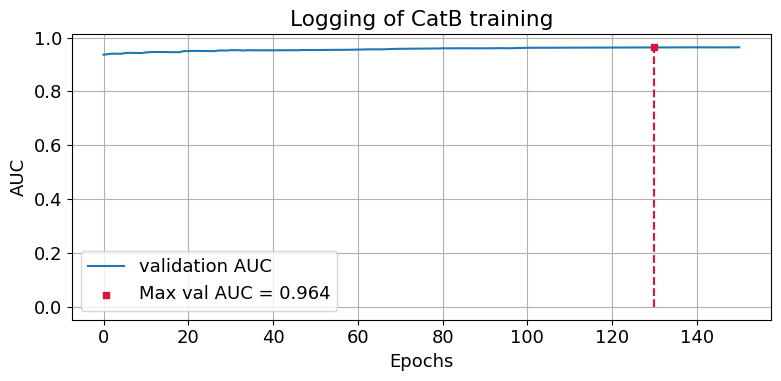

In [289]:
VisualizeLogsWExtrVal(x_Epoch_range if mdl == 'XGB' else c_Epoch_range, x_Train_metrics if mdl == 'XGB' else None,
                      x_Test_metrics if mdl == 'XGB' else c_Test_metrics, x_Keys if mdl == 'XGB' else c_Keys,
                      x_Metrics if mdl == 'XGB' else c_Metrics, x_log_keys if mdl == 'XGB' else c_log_keys,
                      x_log_metrics if mdl == 'XGB' else c_log_metrics, model = mdl, extr = 'Max', save=True, log_path=log_path,
                      image_path=image_path, title = f'{mdl}-{Version}_log_{trees}')

In [145]:
XGB_Classifier.save_model(model_path / f'XGB-{Version}_autoWeights_{trees}.json')

In [132]:
CB_Classifier.save_model(model_path / f'CatB-{Version}_autoWeights_{trees}.cbm')

In [125]:
from sklearn.metrics import roc_auc_score, f1_score
def AUROC_postfactory(model, TestDataset, TestLabels, istorch = False):
    if istorch:
        PredictedLabels = model(TestDataset.float()).detach().numpy()
    else:
        PredictedLabels = model.predict_proba(TestDataset)[:, 1]
    PL_np, TL_np = np.asarray(model.predict(TestDataset)).flatten(), np.asarray(TestLabels).flatten()
    print(f'0\'s: {(TL_np[TL_np==0]==0).sum()} - {(PL_np[TL_np==0]==TL_np[TL_np==0]).sum()}')
    print(f'1\'s: {(TL_np[TL_np==1]==1).sum()} - {(PL_np[TL_np==1]==TL_np[TL_np==1]).sum()}')
    return roc_auc_score(np.asarray(TestLabels).flatten(), np.asarray(PredictedLabels).flatten())
def F1_postfactory(model, TestDataset, TestLabels, istorch = False):
    if istorch:
        PredictedLabels = model(TestDataset.float()).round().int().detach().numpy()
    else:
        PredictedLabels = model.predict(TestDataset)
    return f1_score(np.asarray(TestLabels).flatten(), np.asarray(PredictedLabels).flatten())

In [146]:
AUROC_postfactory(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)

0's: 483 - 421
1's: 2908 - 2733


np.float64(0.9501215323758833)

In [147]:
BoostDict = {'Model': f'{mdl}-{Version}_autoWeights_{trees}',
        'bestTime':  xgbBestTime if mdl == 'XGB' else cbBestTime, 'totalTime': xgbTotalTime if mdl == 'XGB' else cbTotalTime}
BoostDict['AUROCIndex'] = AUROC_postfactory(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)
BoostDict['F1Index'] = F1_postfactory(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)
records_file = log_path / 'records.xls'
BoostDF = pd.DataFrame(BoostDict, index=[0])
if not records_file.exists():
    BoostDF.to_excel(records_file, index=False)
else:
    temp = pd.read_excel(records_file)
    last_row = len(temp)
    with pd.ExcelWriter(records_file, mode='a', if_sheet_exists='overlay') as writer:
        BoostDF.to_excel(writer, index=False, header = False, startrow = last_row+1)

0's: 483 - 421
1's: 2908 - 2733


In [148]:
def MakePrediction(model, X, Y):
    N = np.random.randint(0, len(X))
    print(f'Истинный buyout_flag: {Y[N][0]}')
    print(f'Предсказанный buyout_flag: {model.predict([X[N]])[0]}')

In [151]:
MakePrediction(XGB_Classifier, TestDataset, TestLabels)

Истинный buyout_flag: 0
Предсказанный buyout_flag: 0


<h1>Нейросетевые модели</h1>

In [19]:
from torch import nn
from torchsummary import summary
#import torchvision
#from torchvision import transforms
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import Variable
#from torch import onnx

In [46]:
from sklearn.metrics import roc_auc_score, f1_score
def AUROC_postfactory(model, TestDataset, TestLabels, istorch = False):
    if istorch:
        PredictedLabels = model(TestDataset.float()).detach().numpy()
    else:
        PredictedLabels = model.predict_proba(TestDataset)[:, 1]
    return roc_auc_score(np.asarray(TestLabels).flatten(), np.asarray(PredictedLabels).flatten())
def F1_postfactory(model, TestDataset, TestLabels, istorch = False):
    if istorch:
        PredictedLabels = model(TestDataset.float()).round().int().detach().numpy()
    else:
        PredictedLabels = model.predict(TestDataset)
    return f1_score(np.asarray(TestLabels).flatten(), np.asarray(PredictedLabels).flatten())

In [20]:
class DatasetNLabels():
  def __init__(self, data, labels, shuffle = False, batch_size = 1):
    self.data = Variable(th.tensor(np.asarray(data))).unsqueeze(1)
    self.labels = th.tensor(np.asarray(labels)).unsqueeze(1)
    self.shuffle = shuffle
    self.batch_size = batch_size
  def __len__(self):
    return len(self.data)
  def __getitem__(self, idx):
    return (self.data[idx], self.labels[idx])
  def __iter__(self):
    if self.shuffle:
      perm = np.random.permutation(len(self.data))#, seed = datetime.now().microsecond)
      self.data = Variable(th.tensor(np.asarray([self.data[i] for i in perm])))
      self.labels = th.tensor(np.asarray([self.labels[i] for i in perm]))
    for i in range(0, len(self.data), self.batch_size):
      if i + self.batch_size > len(self.data):
        yield (self.data[i:], self.labels[i:])
      else:
        yield (self.data[i:i+self.batch_size], self.labels[i:i+self.batch_size])

In [21]:
shuff = True
batch_size = 200
Train = DatasetNLabels(TrainDataset, TrainLabels, shuffle = shuff, batch_size= batch_size)
del TrainDataset, TrainLabels
gc.collect()
Validation = DatasetNLabels(TestDataset, TestLabels, shuffle = shuff, batch_size= batch_size)
del TestDataset, TestLabels
gc.collect()

0

In [40]:
log_path = ml_path / 'Logs'
image_path = ml_path / 'Images'
model_path = ml_path / 'Models'

In [364]:
shuff = True
batch_size = 200
Train = DataLoader(TensorDataset(th.tensor(TrainDataset), th.tensor(TrainLabels)), shuffle = shuff, batch_size= batch_size)
Validation = DataLoader(TensorDataset(th.tensor(TestDataset), th.tensor(TestLabels)), shuffle = shuff, batch_size= batch_size)

ValueError: only one element tensors can be converted to Python scalars

In [22]:
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
print(device)

cpu


In [23]:
class NNBase(nn.Module):
    def __init__(self, L):
        super(NNBase, self).__init__()
        self.actRL = nn.ReLU()
        self.actTH = nn.Tanh()
        self.actSIG = nn.Sigmoid()
        self.actSM = nn.Softmax(dim=1)
        self.poolMX = nn.MaxPool1d(kernel_size=2, stride=2, return_indices=False)
        self.poolAVG = nn.AvgPool1d(kernel_size=2, stride=2)
        self.lin12 = nn.Linear(L, 2*L)
        self.bnorm1 = nn.BatchNorm1d(num_features = 1)
        self.lin23 = nn.Linear(2*L, 3*L)
        self.bnorm2 = nn.BatchNorm1d(num_features = 1)
        self.lin24 = nn.Linear(2*L, 4*L)
        self.lin31 = nn.Linear(3*L, L)
        self.lin21 = nn.Linear(2*L, L)
        self.bnorm3 = nn.BatchNorm1d(num_features = 1)
        self.lin10 = nn.Linear(L, 1)
        self.bnorm4 = nn.BatchNorm1d(num_features = 1)
        self.dpt = nn.Dropout(p=0.3)
        self.skip = nn.Identity()

In [37]:
class SimpleLinearM1(NNBase):
    def __init__(self, L):
        super(SimpleLinearM1, self).__init__(L)
    def forward(self, x):
        x = self.actRL(self.bnorm1(self.lin12(x)))

        x = self.dpt(self.actRL(self.bnorm2(self.lin23(x))))

        x = self.actRL(self.bnorm3(self.lin31(x)))

        x = self.actSIG(self.dpt(self.bnorm4(self.lin10(x))))
        return x

In [25]:
class SimpleLinearM2(NNBase):
    def init(self, L):
        super(SimpleLinearM2, self).__init__(L)
    def forward(self, x):
        x = self.actRL(self.bnorm1(self.lin12(x)))
        
        res = x.clone()

        x = self.dpt(self.actRL(self.bnorm2(self.lin24(x))))

        x = self.poolMX(x)
        x+=self.skip(res)

        x = self.actRL(self.bnorm3(self.lin21(x)))

        x = self.actSIG(self.dpt(self.bnorm4(self.lin10(x))))
        return x

In [378]:
L = len(Features_titles)
model = SimpleLinearM2(L).to(device)
summary(model, input_size=(1, L))
del model
gc.collect()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 66]           2,244
       BatchNorm1d-2                [-1, 1, 66]               2
              ReLU-3                [-1, 1, 66]               0
            Linear-4               [-1, 1, 132]           8,844
       BatchNorm1d-5               [-1, 1, 132]               2
              ReLU-6               [-1, 1, 132]               0
           Dropout-7               [-1, 1, 132]               0
         MaxPool1d-8                [-1, 1, 66]               0
          Identity-9                [-1, 1, 66]               0
           Linear-10                [-1, 1, 33]           2,211
      BatchNorm1d-11                [-1, 1, 33]               2
             ReLU-12                [-1, 1, 33]               0
           Linear-13                 [-1, 1, 1]              34
      BatchNorm1d-14                 [-

6276

In [73]:
modelTitle = 'SimpleLinearM2'
optimizerTitle = 'Adam'

In [27]:
!pip install torchmetrics
from torchmetrics.classification import BinaryAUROC, BinaryF1Score

In [74]:
model = SimpleLinearM2(len(Features_titles)).to(device)
optimizer = th.optim.Adam(model.parameters(), lr=0.001)
decayRate = 0.96
lr_scheduler = th.optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=decayRate)
max_running_index = -1
patience = 20
curr_patience = patience
bestModel = 0
epochs = 100
startT = datetime.now()
bestTime = 0
totalTime = 0
log_list = {'Epochs': [], 'TrainAUROCIndex': [], 'TrainF1Index': [],'ValAUROCIndex': [], 'ValF1Index': []}
train_bce = nn.BCELoss()
val_bce = nn.BCELoss()
train_auroc = BinaryAUROC()
val_auroc = BinaryAUROC()
train_f1 = BinaryF1Score(threshold=0.5)
val_f1 = BinaryF1Score(threshold=0.5)
for epoch in tqdm(range(epochs)):
    AUROCRunningIndex = []
    ValAUROCRunningIndex = []
    F1RunningIndex = []
    ValF1RunningIndex = []
    for inputs, labels in Train:
        optimizer.zero_grad()

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(Variable(inputs.float()))
        BCELoss = train_bce(outputs.float(), labels.float())
        AUROCIndex = train_auroc(outputs.float(), labels.float())
        F1Index = train_f1(outputs.float(), labels.float())
        

        AUROCRunningIndex.append(AUROCIndex.item())
        F1RunningIndex.append(F1Index.item())

        BCELoss.backward()
        optimizer.step()
        lr_scheduler.step()

    for inputs, labels in Validation:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs.float())
        ValAUROCIndex = val_auroc(outputs.float(), labels.float())
        ValF1Index = val_f1(outputs.float(), labels.float())

        ValAUROCRunningIndex.append(ValAUROCIndex.item())
        ValF1RunningIndex.append(ValF1Index.item())
    log_list['Epochs'].append(epoch)
    log_list['TrainAUROCIndex'].append(np.mean(np.array(AUROCRunningIndex)))
    log_list['TrainF1Index'].append(np.mean(np.array(F1RunningIndex)))
    log_list['ValAUROCIndex'].append(np.mean(np.array(ValAUROCRunningIndex)))
    log_list['ValF1Index'].append(np.mean(np.array(ValF1RunningIndex)))
    if np.mean(np.array(ValAUROCRunningIndex)) > max_running_index:
        max_running_index = np.mean(np.array(ValAUROCRunningIndex))
        curr_patience = patience
    else:
        if curr_patience == patience:
            endT = datetime.now()
            bestTime = str(endT - startT).split('.')[0]
            bestModel = model
        curr_patience -= 1
    if curr_patience == 0:
        endT = datetime.now()
        totalTime = str(endT - startT).split('.')[0]
        break
    if epoch == epochs-1:
        endT = datetime.now()
        totalTime = str(endT - startT).split('.')[0]
        if curr_patience == patience:
            bestTime = str(endT - startT).split('.')[0]
            bestModel = model
th.save(bestModel.state_dict(), model_path / f'{modelTitle}_({optimizerTitle}, {device}).pth')
NNlog = pd.DataFrame(log_list)
NNlog.to_csv(log_path / f'{modelTitle}_({optimizerTitle}, {device}).csv')
NNDict = {'Model': f'{modelTitle}_({optimizerTitle}, {device})',
        'bestTime': bestTime, 'totalTime': totalTime}
NNDict['AUROCIndex'] = AUROC_postfactory(bestModel, Validation.data, Validation.labels, istorch = True)
NNDict['F1Index'] = F1_postfactory(bestModel, Validation.data, Validation.labels, istorch = True)
NNDict = pd.DataFrame(NNDict, index=[0])
records_file = log_path / 'records.xls'
if not records_file.exists():
    NNDict.to_excel(records_file, index=False)
else:
    temp = pd.read_excel(records_file)
    last_row = len(temp)
    with pd.ExcelWriter(records_file, mode='a', if_sheet_exists='overlay') as writer:
        NNDict.to_excel(writer, index=False, header = False, startrow = last_row+1)

 43%|██████████████████████████████████▊                                              | 43/100 [02:07<02:48,  2.96s/it]


In [285]:
def NNVisualizeLogsWExtrVal(Epoch_range, Train_metrics, Test_metrics, Keys, Metrics, log_keys, log_metrics, model, extr = 'Min', kernel=None, save=False, log_path = '', image_path = '', title='1'):
  fig, ax = plt.subplots(len(Metrics), figsize = (8, 4*len(Metrics)))
  font = {'font.size': 13}
  plt.rcParams.update(font)
  if len(Metrics) == 1:
    Extr_metric = Test_metrics.min() if extr == 'Min' else Test_metrics.max()
    Extr_epoch = Epoch_range[np.argmin(Test_metrics)] if extr == 'Min' else Epoch_range[np.argmax(Test_metrics)]
    ax.plot(Epoch_range, Train_metrics, label = f'{Keys[log_keys[0]]} {Metrics[log_metrics[0]]}', zorder = 2)
    ax.plot(Epoch_range, Test_metrics, label = f'{Keys[log_keys[1]]} {Metrics[log_metrics[0]]}', zorder = 3)
    ax.scatter(Extr_epoch, Extr_metric, c = 'crimson', marker='s', s=20, label = f'{extr} val {Metrics[log_metrics[0]]} = {Extr_metric:.3f}', zorder = 4)
    ax.plot([Extr_epoch, Extr_epoch], [0, Extr_metric], c = 'crimson', linestyle = '--')
    ax.legend(loc=0)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(Metrics[log_metrics[0]])
    if kernel is not None:
      ax.set_title(f'Logging of {model} training (kernel = {kernel})')
    else:
      ax.set_title(f'Logging of {model} training')
    ax.grid(True, zorder = 1)
  else:
    if kernel is not None:
      ax[0].set_title(f'Logging of {model} training (kernel = {kernel})')
    else:
      ax[0].set_title(f'Logging of {model} training')
    for i, metric in enumerate(log_metrics):
      Extr_epoch = Epoch_range[np.argmin(Test_metrics[metric])] if extr == 'Min' else Epoch_range[np.argmax(Test_metrics[metric])]
      Extr_metric = Test_metrics[metric][Extr_epoch]
      ax[i].plot(Epoch_range, Train_metrics[metric], label = f'{Keys[log_keys[0]]} {Metrics[metric]}', zorder = 2)
      ax[i].plot(Epoch_range, Test_metrics[metric], label = f'{Keys[log_keys[1]]} {Metrics[metric]}', zorder = 3)
      ax[i].scatter(Extr_epoch, Extr_metric, c = 'crimson', marker='s', s=20, label = f'{extr} val {Metrics[metric]} = {Extr_metric:.3f}', zorder = 4)
      ax[i].plot([Extr_epoch, Extr_epoch], [0, Extr_metric], c = 'crimson', linestyle = '--')
      ax[i].legend(loc=0)
      ax[i].set_xlabel('Epochs')
      ax[i].set_ylabel(Metrics[metric])
      ax[i].grid(True, zorder = 1)
  if save:
    Dict = {'Epochs': Epoch_range}
    if len(Metrics) == 1:
      Dict[f'{Keys[log_keys[0]]}_{Metrics[log_metrics[0]]}'] = Train_metrics
      Dict[f'{Keys[log_keys[1]]}_{Metrics[log_metrics[0]]}'] = Test_metrics
    else:
      for metric in log_metrics:
        Dict[f'{Keys[log_keys[0]]}_{Metrics[metric]}'] = Train_metrics[metric]
        Dict[f'{Keys[log_keys[1]]}_{Metrics[metric]}'] = Test_metrics[metric]
    df = pd.DataFrame(Dict)
    df.to_csv(log_path / (title+'.csv'))
    fig.tight_layout()
    fig.savefig(image_path / (title+'.png'))
  plt.show()

In [75]:
Epochs = np.array([i for i in NNlog['Epochs'].to_dict().values()])
cols = [i for i in NNlog.columns if i!='Epochs']
Train_metrics = {i[5:]: [j for j in NNlog[i].to_dict().values()] for i in cols if ('Train' in i)}
Test_metrics = {i[3:]: [j for j in NNlog[i].to_dict().values()] for i in cols if ('Val' in i)}
Keys = ['train', 'val']
log_metrics = [i for i in Train_metrics.keys()]
log_keys = [0, 1]
Metrics = {'AUROCIndex': 'ROC-AUC', 'F1Index': 'F1'}

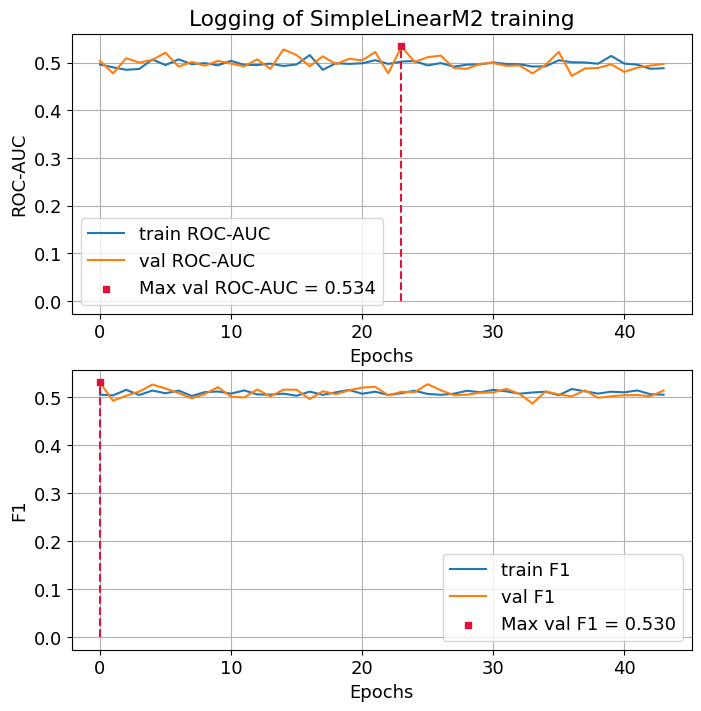

In [76]:
NNVisualizeLogsWMinVal(Epochs, Train_metrics, Test_metrics, Keys, Metrics, log_keys,
                     log_metrics, modelTitle.replace('_', ' '), extr = 'Max', save = False, log_path= log_path,
                     image_path= image_path, title = f'{modelTitle}_log_({optimizerTitle}, {device})')

<h1>Стьюденто- и Фишероподобные критерии</h1>

In [161]:
!pip install shap
import shap

In [284]:
from scipy import stats

def tstar_student(alpha, df):
    return stats.t.ppf(1-alpha/2, df)

def create_student_table(alpha_values=[0.1, 0.05, 0.02, 0.01, 0.005], 
                         df_max=30):
    table_data = {}
    
    for alpha in alpha_values:
        column_name = f'α={alpha}'
        column_data = []
        
        for df in range(1, df_max + 1):
            t_critical = stats.t.ppf(1 - alpha/2, df)
            column_data.append(tstar_student(alpha, df))
        
        table_data[column_name] = column_data
    
    df_index = list(range(1, df_max + 1))
    table = pd.DataFrame(table_data, index=df_index)
    table.index.name = 'df'
    
    return table
#Изначально используется критерий Стьюдента для оценки важности признаков. Критерий Фишера используется для оценки значимости модели в целом.
#Напрямую t-критерий для градиентного бустинга рассчитать не получится. Аналоги - permutation importance, SHAP
from sklearn.inspection import permutation_importance
def PerImp(model, X_test, y_test):
    return permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
def SHAP(model, X_train, X_test, features):
    explainer = shap.TreeExplainer(model, np.asarray(X_train), feature_names = features)
    shap_values = explainer.shap_values(np.asarray(X_test))
    explanation = explainer(np.asarray(X_test))
    return shap_values, explanation
def SSerr(y1, y2):
    return np.sum((y1-y2)**2)
def SSreg(y1, y2):
    return np.sum((y2-np.mean(y1))**2)
def sigj(y1, y2, xj, n, m):
    return np.sqrt(SSerr(y1, y2)/((n-m)*np.sum((xj-np.mean(xj))**2)))
def MSR(y1, y2, m):
    return SSreg(y1, y2)/m
def MSE(y1, y2, n, m):
    return SSerr(y1, y2)/(n-m-1)
def F_test(y1, y2, n, m):
    return MSR(y1, y2, m)/MSE(y1, y2, n, m)
def Fstar_fisher(alpha, df1, df2):
    return stats.f.ppf(1 - alpha, df1, df2)
def F_test_check(y1, y2, n, m, alpha):
    F = F_test(y1, y2, n, m)
    Fstar = Fstar_fisher(alpha, n-m-1, m)
    if F<Fstar:
        print(f'F = {F}, F* = {Fstar}\nСправедлива нулевая гипотеза: модель не значима.')
    else:
        print(f'F = {F}, F* = {Fstar}\nСправедлива первая гипотеза: модель значима.')
def create_fisher_table(alpha=0.05, df1_max=30, df2_max=30):
    df1_values = list(range(1, df1_max + 1))
    df2_values = list(range(1, df2_max + 1))
    
    table_data = {}
    
    for df1 in df1_values:
        column_data = []
        for df2 in df2_values:
            column_data.append(Fstar_fisher(alpha, df1, df2))
        table_data[f'df1={df1}'] = column_data
    
    table = pd.DataFrame(table_data, index=df2_values)
    table.index.name = 'df2'
    
    return table
Categorical_division = {'Category': ['column']}
def DrawCategories(Categorical_dict, features):
    return {key: [features.index(i) for i in cols] for key, cols in Categorical_dict.items()}
def drawPerImp(permutation_importances, features, mdl, save=False, image_path = '', title='1'):
    sorted_idx = permutation_importances.importances_mean.argsort()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(sorted_idx)), permutation_importances.importances_mean[sorted_idx])
    ax.set_yticks(range(len(sorted_idx)), [f'{features[i]}' for i in sorted_idx], fontsize = 8)
    ax.set_xlabel('Permutation Importance')
    ax.set_title(f'Permutation Importance {mdl}')
    plt.tight_layout()
    plt.show()
    if save:
        fig.savefig(image_path / (title+'.png'))

def drawCatPerImp(permutation_importances, Categorical_dict, features, mdl, save=False, image_path = '', title='1'):
    CatPerms = np.asarray([permutation_importances.importances_mean[val].sum() for key, val in DrawCategories(Categorical_dict, features)])
    Categories = [key for key in Categorical_dict.key()]
    sorted_idx = CatPerms.argsort()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(sorted_idx)), CatPerms[sorted_idx])
    ax.set_yticks(range(len(sorted_idx)), [f'{Categories[i]}' for i in sorted_idx], fontsize = 8)
    ax.set_xlabel('Categorical Permutation Importance')
    ax.set_title(f'Categorical Permutation Importance {mdl}')
    plt.tight_layout()
    plt.show()
    if save:
        fig.savefig(image_path / ('Categorical'+title+'.png'))

def SHAP_plot(shap_vals, explanation, TestDataset, features, mdl, max_display = 20, plot_type = 'Beeswarm', save = False, image_path = '', title = '1'):
    fig = plt.figure()
    plt.title(f'{plot_type} plot {mdl}')
    if plot_type == 'Beeswarm':
        shap.plots.beeswarm(explanation, max_display = max_display)
    elif plot_type == 'Summary':
        shap.summary_plot(shap_vals, TestDataset, feature_names=features)
    elif plot_type == 'Waterfall':
        shap.plots.waterfall(explanation[0], max_display = max_display)
    elif plot_type == 'Bar':
        shap.plots.bar(explanation, max_display = max_display)
    elif plot_type == 'Heatmap':
        shap.plots.heatmap(explanation, max_display = max_display)
    fig.tight_layout()
    if save:
        fig.savefig(image_path / (plot_type+'_'+title+'.png'))

def SHAP_categorical_plot(shap_vals, explanation, TestDataset, Categorical_dict, features, mdl, max_display = 20, plot_type = 'Beeswarm', save = False, image_path = '', title = '1'):
    fig = plt.figure()
    plt.title(f'{plot_type} categorical plot {mdl}')
    Categorical = DrawCategories(Categorical_dict, features)
    Categories = [key for key in Categorical_dict.key()]
    from copy import deepcopy as copy
    if plot_type == 'Beeswarm':
        exp_temp = copy(explanation)
        exp_temp.feature_names = Categories
        exp_temp.values = np.array([exp_temp.values[:, val].sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.data = np.array([exp_temp.data[:, val].sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.base_values = np.array([exp_temp.base_values[val].sum() for val in Categorical.values()])
        shap.plots.beeswarm(exp_temp, max_display = max_display)
    elif plot_type == 'Summary':
        shap_vals_temp = np.array([copy(shap_vals)[:, val].sum(axis = 1) for val in Categorical.values()]).T
        shap.summary_plot(shap_vals, np.array([np.asarray(TestDataset)[:, val].sum(axis = 1) for val in Categorical.values()]).T, feature_names=Categories)
    elif plot_type == 'Waterfall':
        exp_temp = copy(explanation)
        exp_temp.feature_names = Categories
        exp_temp.values = np.array([exp_temp.values[:, val].sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.data = np.array([exp_temp.data[:, val].sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.base_values = np.array([exp_temp.base_values[val].sum() for val in Categorical.values()])
        shap.plots.waterfall(exp_temp[0], max_display = max_display)
    elif plot_type == 'Bar':
        exp_temp = copy(explanation)
        exp_temp.feature_names = Categories
        exp_temp.values = np.array([np.abs(exp_temp.values[:, val]).sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.data = np.array([np.abs(exp_temp.data[:, val]).sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.base_values = np.array([np.abs(exp_temp.base_values[val]).sum() for val in Categorical.values()])
        shap.plots.bar(exp_temp, max_display = max_display)
    elif plot_type == 'Heatmap':
        exp_temp = copy(explanation)
        exp_temp.feature_names = Categories
        exp_temp.values = np.array([exp_temp.values[:, val].sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.data = np.array([exp_temp.data[:, val].sum(axis = 1) for val in Categorical.values()]).T
        exp_temp.base_values = np.array([exp_temp.base_values[val].sum() for val in Categorical.values()])
        shap.plots.heatmap(exp_temp, max_display = max_display)
    fig.tight_layout()
    if save:
        fig.savefig(image_path / (plot_type+'_categorical_'+title+'.png'))   

In [153]:
n, m = np.asarray(TestDataset).shape
F_test_check(np.asarray(TestLabels).flatten(), np.asarray(XGB_Classifier.predict(TestDataset)).flatten(), n, m, 1e-16)

F = 194.5937083808758, F* = 17.454941627360146
Справедлива первая гипотеза: модель значима.


In [185]:
mdl = 'XGB'

In [186]:
perimp = PerImp(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)

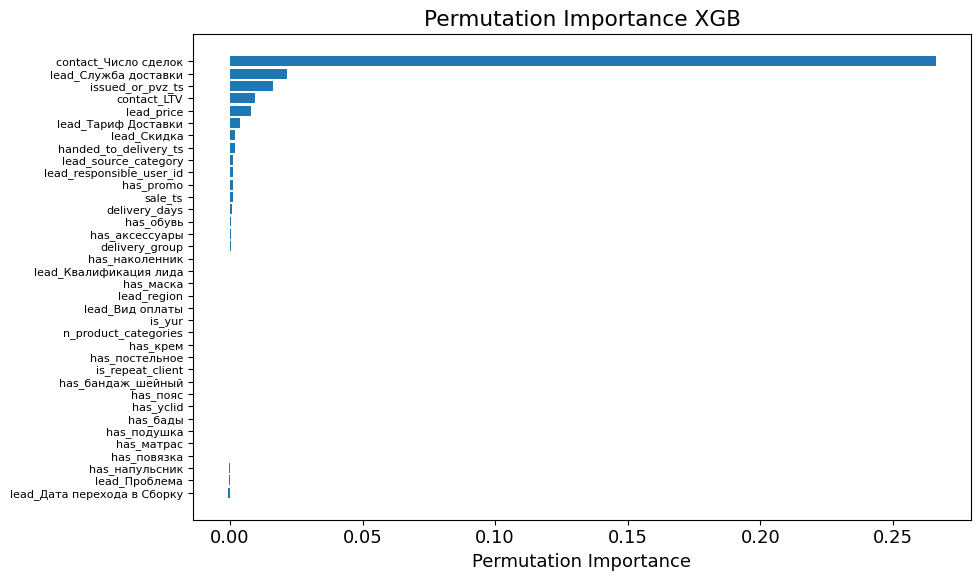

In [187]:
drawPerImp(perimp, Features_titles, mdl, save = True, image_path = image_path, title = f'Permutation_importance_{mdl}-{Version}_{trees}')

In [264]:
shap_vals, explanation = SHAP(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TrainDataset, TestDataset, Features_titles)

 99%|===================| 3353/3391 [00:20<00:00]        

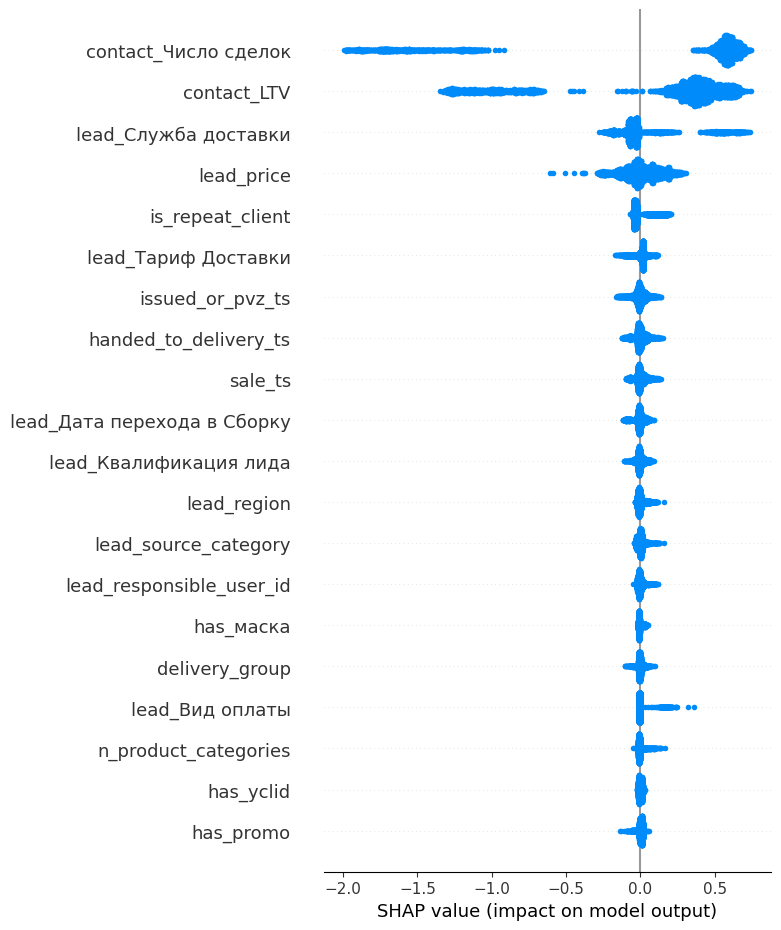

In [163]:
shap.summary_plot(shap_vals, TestDataset, feature_names=Features_titles)

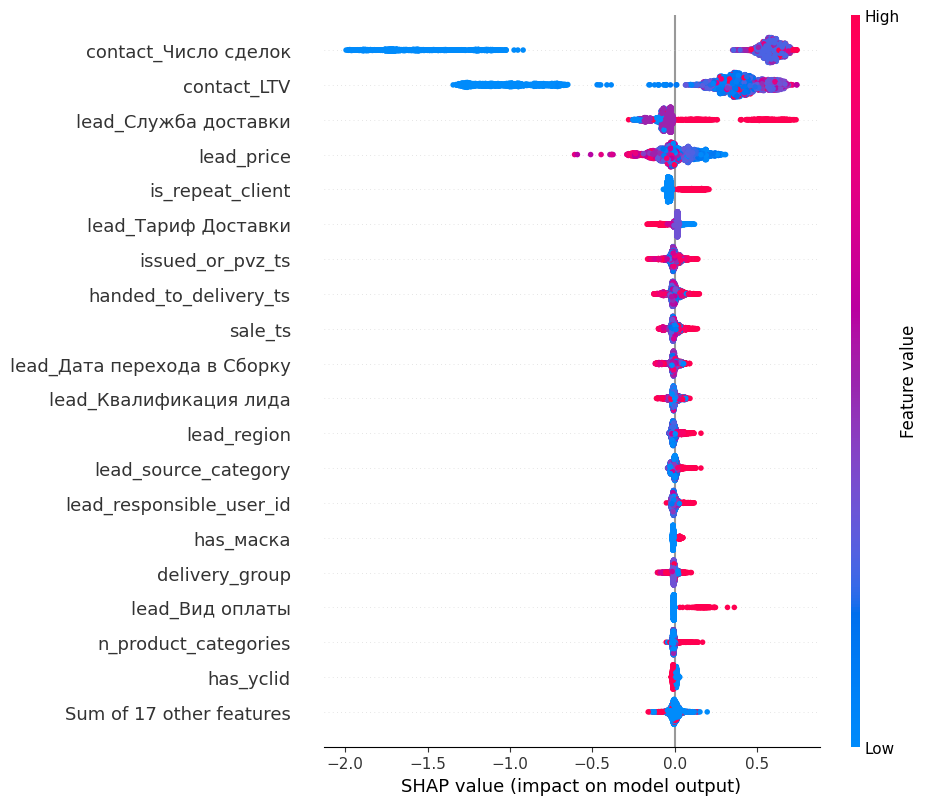

In [164]:
shap.plots.beeswarm(explanation, max_display = 20)

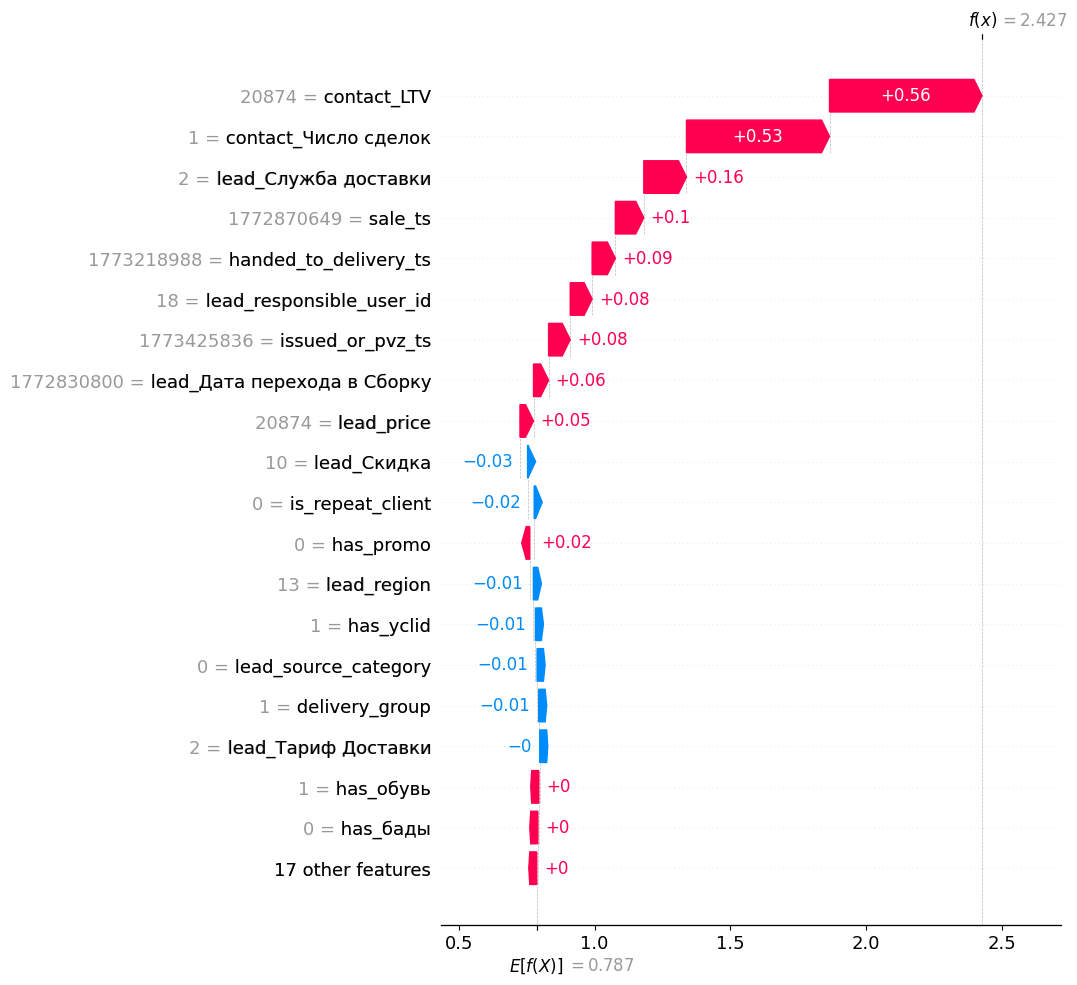

In [165]:
shap.plots.waterfall(explanation[0], max_display = 20)

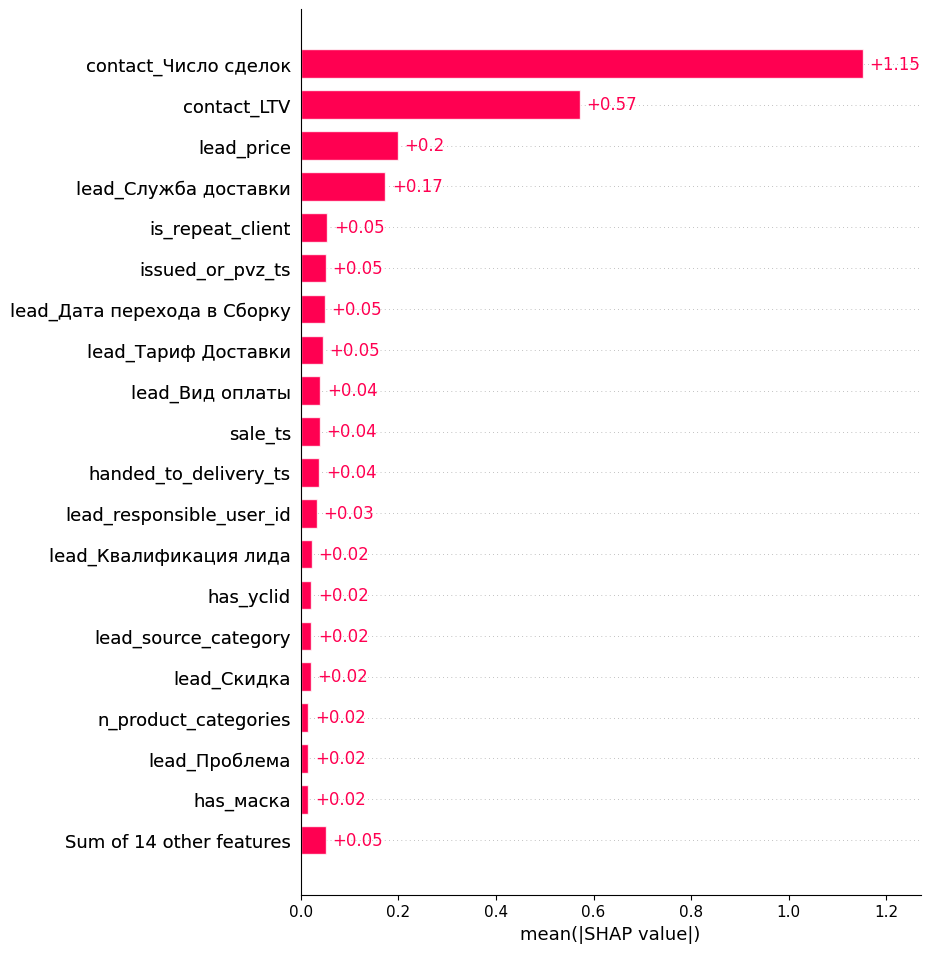

In [331]:
shap.plots.bar(explanation, max_display = 20)

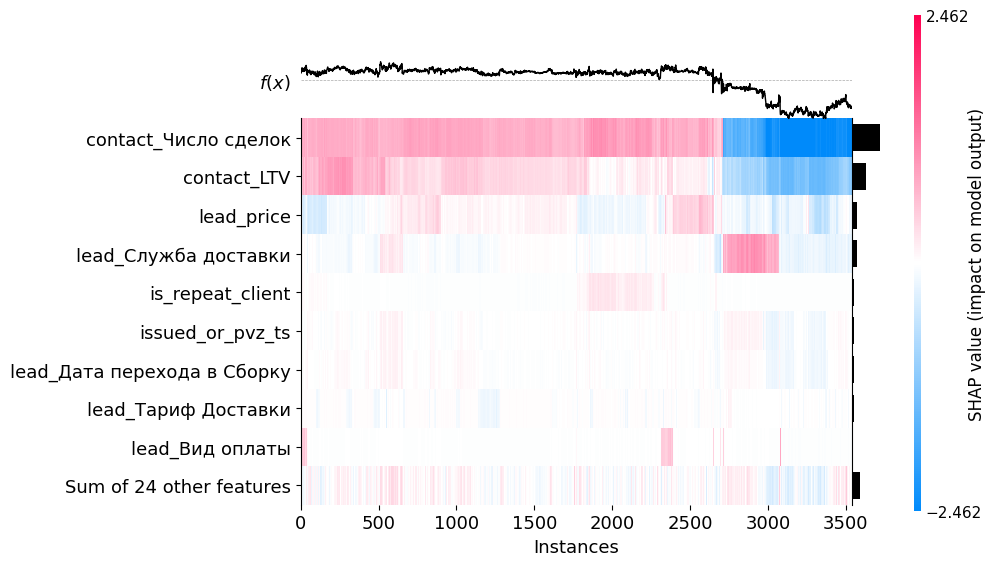

<Axes: xlabel='Instances'>

In [333]:
shap.plots.heatmap(explanation)

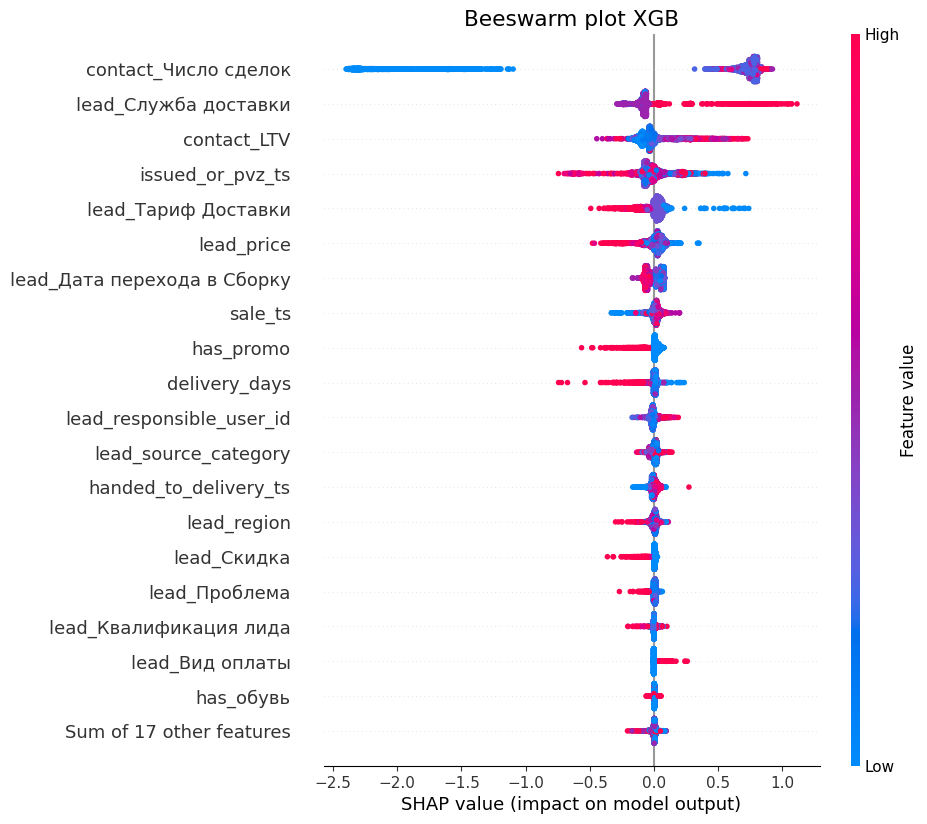

In [223]:
SHAP_plot(shap_vals, explanation, TestDataset, Features_titles, mdl = mdl, max_display = 20, plot_type = 'Beeswarm', save = True,
          image_path = image_path, title = f'{mdl}-{Version}_{trees}')